# Day 08 — Unsupervised Learning & K-Means Clustering

**Mini Project: Customer Segmentation**

## 1. Unsupervised Learning

Unsupervised Learning works with data that has no predefined target labels.

`Data → Model → Discover Patterns`

## 2. Supervised vs Unsupervised

**Supervised:** labelled data, has a target, learns input-output relationships.

**Unsupervised:** unlabelled data, no predefined target, discovers hidden patterns.

## 3. Clustering

Clustering groups similar data points together.

Examples: customer segmentation, market segmentation, grouping similar products.

## 4. K-Means

K-Means is an unsupervised algorithm that divides data into **K clusters** based on similarity.

`K = number of clusters`

## 5. Important Concepts

- Cluster — group of similar points
- Centroid — center of a cluster
- Inertia — measure related to distance from points to assigned centroids
- Elbow Method — helps choose K

## 6. K-Means Algorithm

1. Choose K
2. Initialize centroids
3. Assign points to nearest centroid
4. Recalculate centroids
5. Repeat until clusters stabilize

## 7. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


## 8. Create Customer Dataset

In [2]:
data = {
    "Annual_Income": [15, 16, 17, 40, 42, 45, 80, 85, 90],
    "Spending_Score": [20, 22, 25, 50, 52, 55, 80, 85, 90]
}

df = pd.DataFrame(data)

print(df)


   Annual_Income  Spending_Score
0             15              20
1             16              22
2             17              25
3             40              50
4             42              52
5             45              55
6             80              80
7             85              85
8             90              90


## 9. Inspect Dataset

In [3]:
print(df.head())
print("Shape:", df.shape)
print(df.describe())


   Annual_Income  Spending_Score
0             15              20
1             16              22
2             17              25
3             40              50
4             42              52
Shape: (9, 2)
       Annual_Income  Spending_Score
count       9.000000        9.000000
mean       47.777778       53.222222
std        30.289345       27.316560
min        15.000000       20.000000
25%        17.000000       25.000000
50%        42.000000       52.000000
75%        80.000000       80.000000
max        90.000000       90.000000


## 10. Visualize Raw Data

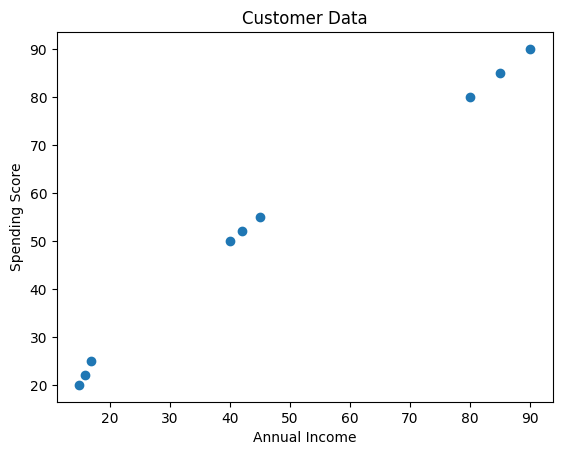

In [4]:
plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Data")
plt.show()


## 11. Prepare Features

In [5]:
X = df[["Annual_Income", "Spending_Score"]]

print(X)


   Annual_Income  Spending_Score
0             15              20
1             16              22
2             17              25
3             40              50
4             42              52
5             45              55
6             80              80
7             85              85
8             90              90


## 12. Create K-Means Model

In [6]:
model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

print(model)


KMeans(n_clusters=3, n_init=10, random_state=42)


## 13. Train K-Means

In [7]:
model.fit(X)

print("K-Means training completed.")


K-Means training completed.


## 14. Get Cluster Labels

In [8]:
labels = model.labels_
print(labels)


[2 2 2 0 0 0 1 1 1]


## 15. Add Cluster Column

In [9]:
df["Cluster"] = labels
print(df)


   Annual_Income  Spending_Score  Cluster
0             15              20        2
1             16              22        2
2             17              25        2
3             40              50        0
4             42              52        0
5             45              55        0
6             80              80        1
7             85              85        1
8             90              90        1


## 16. Get Cluster Centroids

In [10]:
centroids = model.cluster_centers_

print("Centroids:")
print(centroids)


Centroids:
[[42.33333333 52.33333333]
 [85.         85.        ]
 [16.         22.33333333]]


## 17. Visualize Clusters

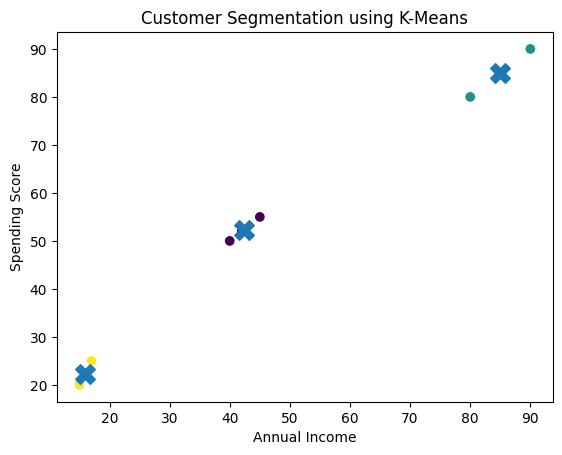

In [11]:
plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    c=df["Cluster"]
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.show()


## 18. Analyze Clusters

In [12]:
cluster_summary = df.groupby("Cluster")[
    ["Annual_Income", "Spending_Score"]
].mean()

print(cluster_summary)


         Annual_Income  Spending_Score
Cluster                               
0            42.333333       52.333333
1            85.000000       85.000000
2            16.000000       22.333333


## 19. Elbow Method

In [13]:
inertia = []

for k in range(1, 10):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)
    inertia.append(model.inertia_)

print(inertia)


[13309.11111111111, 2530.1666666666665, 140.0, 65.0, 40.0, 18.666666666666664, 6.5, 2.5, 0.0]


## 20. Plot Elbow Curve

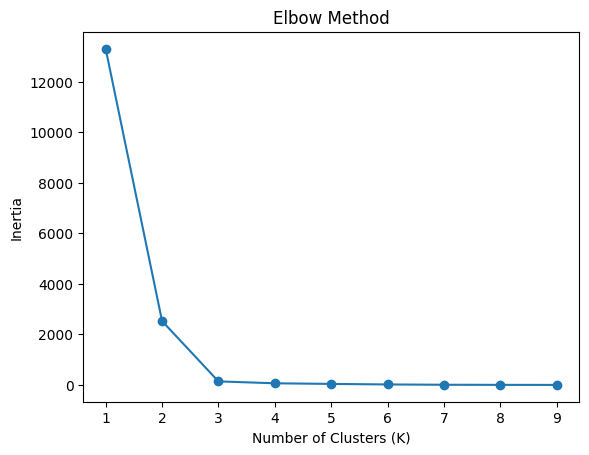

In [14]:
plt.plot(
    range(1, 10),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


## 21. Try Different K Values

In [15]:
for k in [2, 3, 4]:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)

    print(
        "K =", k,
        "| Inertia =", model.inertia_
    )


K = 2 | Inertia = 2530.1666666666665
K = 3 | Inertia = 140.0
K = 4 | Inertia = 65.0


## 22. Feature Scaling

K-Means uses distance, so feature scale can affect clustering.

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled)


[[-1.1477991  -1.28996799]
 [-1.1127815  -1.21231106]
 [-1.0777639  -1.09582565]
 [-0.27235911 -0.12511395]
 [-0.20232391 -0.04745702]
 [-0.09727111  0.06902839]
 [ 1.12834488  1.03974009]
 [ 1.30343288  1.23388243]
 [ 1.47852088  1.42802477]]


## 23. K-Means with Scaled Data

In [17]:
scaled_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

scaled_model.fit(X_scaled)

scaled_labels = scaled_model.labels_

print(scaled_labels)


[2 2 2 0 0 0 1 1 1]


## 24. Visualize Scaled Clusters

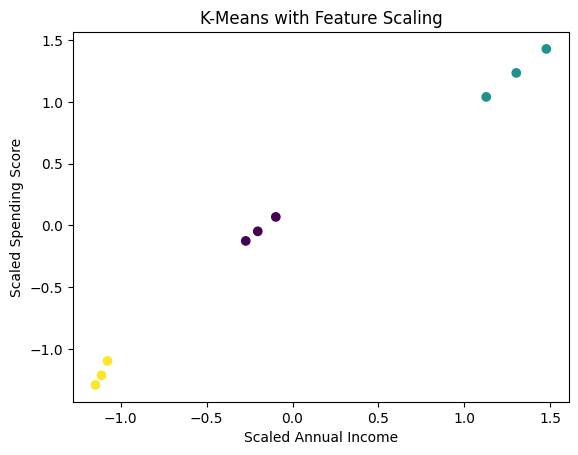

In [18]:
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=scaled_labels
)

plt.xlabel("Scaled Annual Income")
plt.ylabel("Scaled Spending Score")
plt.title("K-Means with Feature Scaling")
plt.show()


## 25. Complete Customer Segmentation Project

Customer Data:
   Annual_Income  Spending_Score  Cluster
0             15              20        2
1             16              22        2
2             17              25        2
3             40              50        0
4             42              52        0
5             45              55        0
6             80              80        1
7             85              85        1
8             90              90        1

Centroids:
[[42.33333333 52.33333333]
 [85.         85.        ]
 [16.         22.33333333]]

Cluster Summary:
         Annual_Income  Spending_Score
Cluster                               
0            42.333333       52.333333
1            85.000000       85.000000
2            16.000000       22.333333


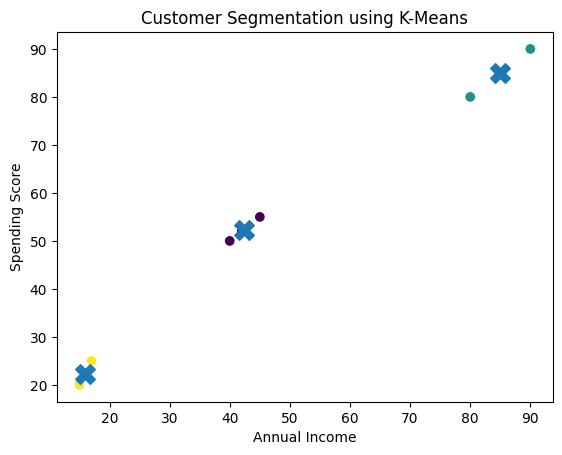

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

data = {
    "Annual_Income": [15, 16, 17, 40, 42, 45, 80, 85, 90],
    "Spending_Score": [20, 22, 25, 50, 52, 55, 80, 85, 90]
}

df = pd.DataFrame(data)

X = df[["Annual_Income", "Spending_Score"]]

model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

model.fit(X)

df["Cluster"] = model.labels_
centroids = model.cluster_centers_

print("Customer Data:")
print(df)

print("\nCentroids:")
print(centroids)

print("\nCluster Summary:")
print(
    df.groupby("Cluster")[
        ["Annual_Income", "Spending_Score"]
    ].mean()
)

plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    c=df["Cluster"]
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.show()


# 🎯 Day 8 Final Flow

`Customer Data → Features → K-Means → Cluster Assignment → Centroids → Cluster Analysis → Business Insights`

### Next: Day 9
**Feature Scaling + Data Preprocessing**